# Demo

Simple demo using `warp_transform()` with a BioTuring logo.

- **Input**: `bioturing_input.png` (RGB image, H x W x 3)
- **Transform**: Affine rotation + scale
- **Output**: Warped image side-by-side with original

In [13]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

from spatialx_transform import warp_transform
from spatialx_transform.transforms import Affine
from spatialx_transform.params import AffineParams

In [14]:
import logging

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)

In [15]:
# Load logo: cv2 reads as [H, W, 3] BGR
img_bgr = cv.imread("bioturing_input.png")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert to [C, H, W] for warp_transform
img_chw = np.transpose(img_rgb, (2, 0, 1))
print(f"Input shape: {img_chw.shape}")

Input shape: (3, 2500, 5000)


In [16]:
# Define a simple affine transform: rotate 15deg + scale 1.2x
angle = 15 * np.pi / 180
s = 1.2
A = [[s * np.cos(angle), -s * np.sin(angle)], [s * np.sin(angle), s * np.cos(angle)]]
b = [0.0, 0.0]

tf = Affine(params=AffineParams(A=A, b=b))
print(f"A = {A}")
print(f"b = {b}")

A = [[np.float64(1.159110991546882), np.float64(-0.3105828541230249)], [np.float64(0.3105828541230249), np.float64(1.159110991546882)]]
b = [0.0, 0.0]


In [20]:
# Preflight
preflight_result = warp_transform(
    img_chw, tf, d=(10, 10), scale=(1.0, 1.0), preflight=True
)
preflight_result

2026-07-06 09:21:26,015 [INFO] spatialx_transform.warp: input: C=3 H=2500 W=5000, d=(10, 10), scale=(1.0, 1.0)
2026-07-06 09:21:26,015 [INFO] spatialx_transform.warp: computing forward bbox (border scan)...
2026-07-06 09:21:26,045 [INFO] spatialx_transform.warp: output: H_dst=4450 W_dst=6572, offset=(0, -777)


PreflightTransformationResult(img_shape=[3, 4450, 6572], offset=(0, -777))

In [18]:
# Warp
result = warp_transform(img_chw, tf, d=(10, 10), scale=(1.0, 1.0), preflight=False)
print(f"Output shape: {result.img.shape}")
print(f"Offset: {result.offset}")

2026-07-06 09:20:38,073 [INFO] spatialx_transform.warp: input: C=3 H=2500 W=5000, d=(10, 10), scale=(1.0, 1.0)
2026-07-06 09:20:38,073 [INFO] spatialx_transform.warp: computing forward bbox (border scan)...
2026-07-06 09:20:38,101 [INFO] spatialx_transform.warp: output: H_dst=4450 W_dst=6572, offset=(0, -777)
2026-07-06 09:20:38,101 [INFO] spatialx_transform.warp: grid: 251x501 = 125751 points, 250000 triangles
2026-07-06 09:20:38,102 [INFO] spatialx_transform.warp: forward-transforming grid points...
2026-07-06 09:20:40,856 [INFO] spatialx_transform.warp: warping 250000 triangles across 3 channel(s)...
2026-07-06 09:20:40,856 [DEBUG] spatialx_transform.warp: processing channel 1/3
2026-07-06 09:20:41,225 [DEBUG] spatialx_transform.warp: triangle 20000/250000
2026-07-06 09:20:41,568 [DEBUG] spatialx_transform.warp: triangle 40000/250000
2026-07-06 09:20:41,909 [DEBUG] spatialx_transform.warp: triangle 60000/250000
2026-07-06 09:20:42,255 [DEBUG] spatialx_transform.warp: triangle 80000/

Output shape: (3, 4450, 6572)
Offset: (0, -777)


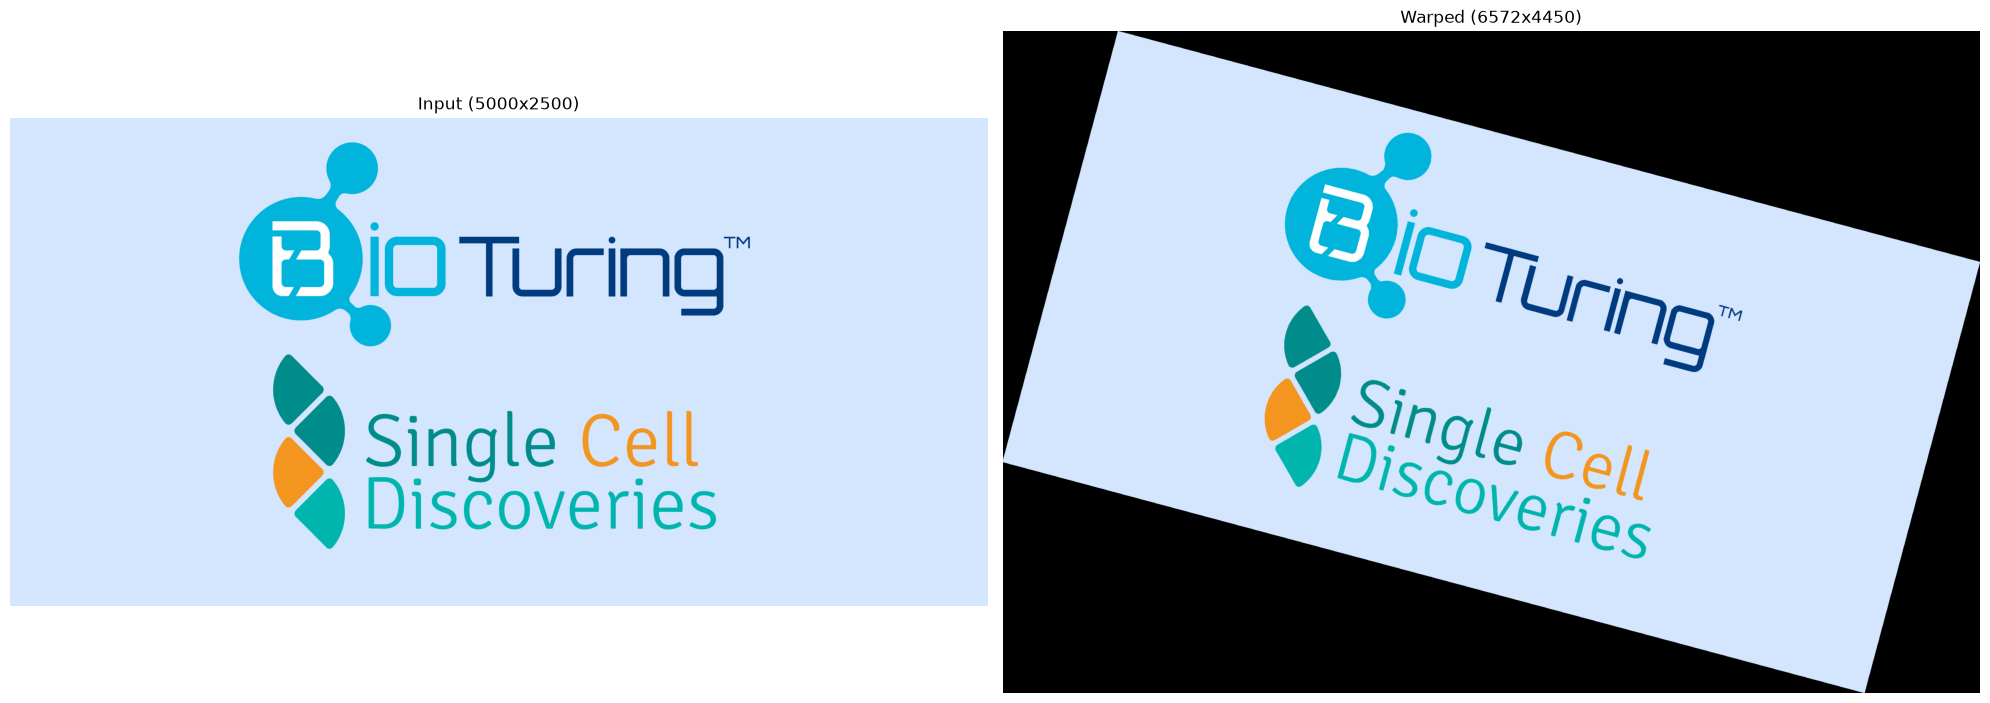

In [19]:
# Convert back to HWC for display
output_rgb = np.transpose(result.img, (1, 2, 0))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Input ({img_rgb.shape[1]}x{img_rgb.shape[0]})")
axes[0].axis("off")
axes[1].imshow(output_rgb)
axes[1].set_title(f"Warped ({output_rgb.shape[1]}x{output_rgb.shape[0]})")
axes[1].axis("off")
plt.tight_layout()
plt.show()